# Co-Authorship Network and Research Community Detection
Alex Bradshaw, 1861973

## About
The goal of this analysis is to map co-author relationships across venues.

## Tasks
1. Map co-author networks within and across venues/conferences
2. Use graph clustering to identify research communities/groups
3. Analyze collaboration patterns (do certain author groups dominate certain venues?)

## Motivations
- Identify tight-knit research communities and key bridge figures who connect disparate groups
- Understand collaboration culture: do certain venues/subfields favor collaboration while others are individual-focused?
- Discover hidden research hierarchies: who are the central figures in each community? How do newcomers break in?
- Reveal informal networks: papers often come from established research groups; understanding these networks provides insights into how research is actually conducted

## Challenges
- Author disambiguation: Same name can refer to different authors; misspellings and name variations make exact matching difficult
- Scale variation: Some authors publish 100+ papers, others 1-2; co-authorship graph has highly skewed degree distribution
- Temporal changes: Research communities evolve; some authors exit, new collaborators emerge; static snapshots miss this dynamic
- Defining "communities": Different clustering algorithms (Louvain, K-clique, etc.) can yield very different community structures

In [1]:
"""Import Dependencies"""
import json
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [2]:
"""Globals/Constants"""
DATA_PATH = './dblp_ref/'

In [3]:
"""Helper/Utility Functions"""
def read_json_lines(file_path):
    """Reads the JSON file at the given path and yeilds each line (record)."""
    with open(file_path) as json_file:
        for line in json_file:
            yield json.loads(line)

In [4]:
"""Load Data"""
frames = []
for file_index in range(4):
    file_name = f'{ DATA_PATH }dblp-ref-{ file_index }.json'
    print(f"Loading file { file_name } ({ file_index + 1 }/4)...")
    frames.append(pd.DataFrame(read_json_lines(file_name)))

print("Concatenating Data Frames...")
papers = pd.concat(frames)
papers

Loading file ./dblp_ref/dblp-ref-0.json (1/4)...
Loading file ./dblp_ref/dblp-ref-1.json (2/4)...
Loading file ./dblp_ref/dblp-ref-2.json (3/4)...
Loading file ./dblp_ref/dblp-ref-3.json (4/4)...
Concatenating Data Frames...


,abstract,authors,n_citation,references,title,venue,year,id
0,The purpose of this study is to develop a lear...,"[Makoto Satoh, Ryo Muramatsu, Mizue Kayama, Ka...",0,"[51c7e02e-f5ed-431a-8cf5-f761f266d4be, 69b625b...",Preliminary Design of a Network Protocol Learn...,international conference on human-computer int...,2013,00127ee2-cb05-48ce-bc49-9de556b93346
1,This paper describes the design and implementa...,"[Gareth Beale, Graeme Earl]",50,"[10482dd3-4642-4193-842f-85f3b70fcf65, 3133714...",A methodology for the physically accurate visu...,visual analytics science and technology,2011,001c58d3-26ad-46b3-ab3a-c1e557d16821
2,This article applied GARCH model instead AR or...,"[Altaf Hossain, Faisal Zaman, Mohammed Nasser,...",50,"[2d84c0f2-e656-4ce7-b018-90eda1c132fe, a083a1b...","Comparison of GARCH, Neural Network and Suppor...",pattern recognition and machine intelligence,2009,001c8744-73c4-4b04-9364-22d31a10dbf1
3,NaN,"[Jea-Bum Park, Byungmok Kim, Jian Shen, Sun-Yo...",0,"[8c78e4b0-632b-4293-b491-85b1976675e6, 9cdc54f...",Development of Remote Monitoring and Control D...,,2011,00338203-9eb3-40c5-9f31-cbac73a519ec
4,NaN,"[Giovanna Guerrini, Isabella Merlo]",2,NaN,Reasonig about Set-Oriented Methods in Object ...,,1998,0040b022-1472-4f70-a753-74832df65266
...,...,...,...,...,...,...,...,...
79002,NaN,"[Hassan Charaf, Peter Ekler, Tamás Mészáros, I...",50,NaN,Mobile Platforms and Multi-Mobile Platform Dev...,Acta Cybernetica,2014,ff5ce050-ea8d-40e8-a25f-c629bed2ff9c
79003,NaN,"[Saul Blecker, Stuart D. Katz, Leora I. Horwit...",0,NaN,Comparison of Approaches for Heart Failure Cas...,,2016,ff5f5e4d-b650-496a-bfdd-91affb718488
79004,NaN,"[Dzmitry Bahdanau, Tom Bosc, Stanisław Jastrzę...",0,NaN,Learning to Compute Word Embeddings on the Fly,,2017,ff8fba62-4bf4-40cd-8555-46b8c64dddd7
79005,NaN,"[Kirsti Askedal, Leif Skiftenes Flak, Eirik Ab...",0,NaN,Reviewing Effects of ICT in Primary Healthcare...,,2017,ff90ffea-c94e-4ac5-a36a-05e1eccd6a76


/tmp/ipykernel_5621/3556330230.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', TOP_N)


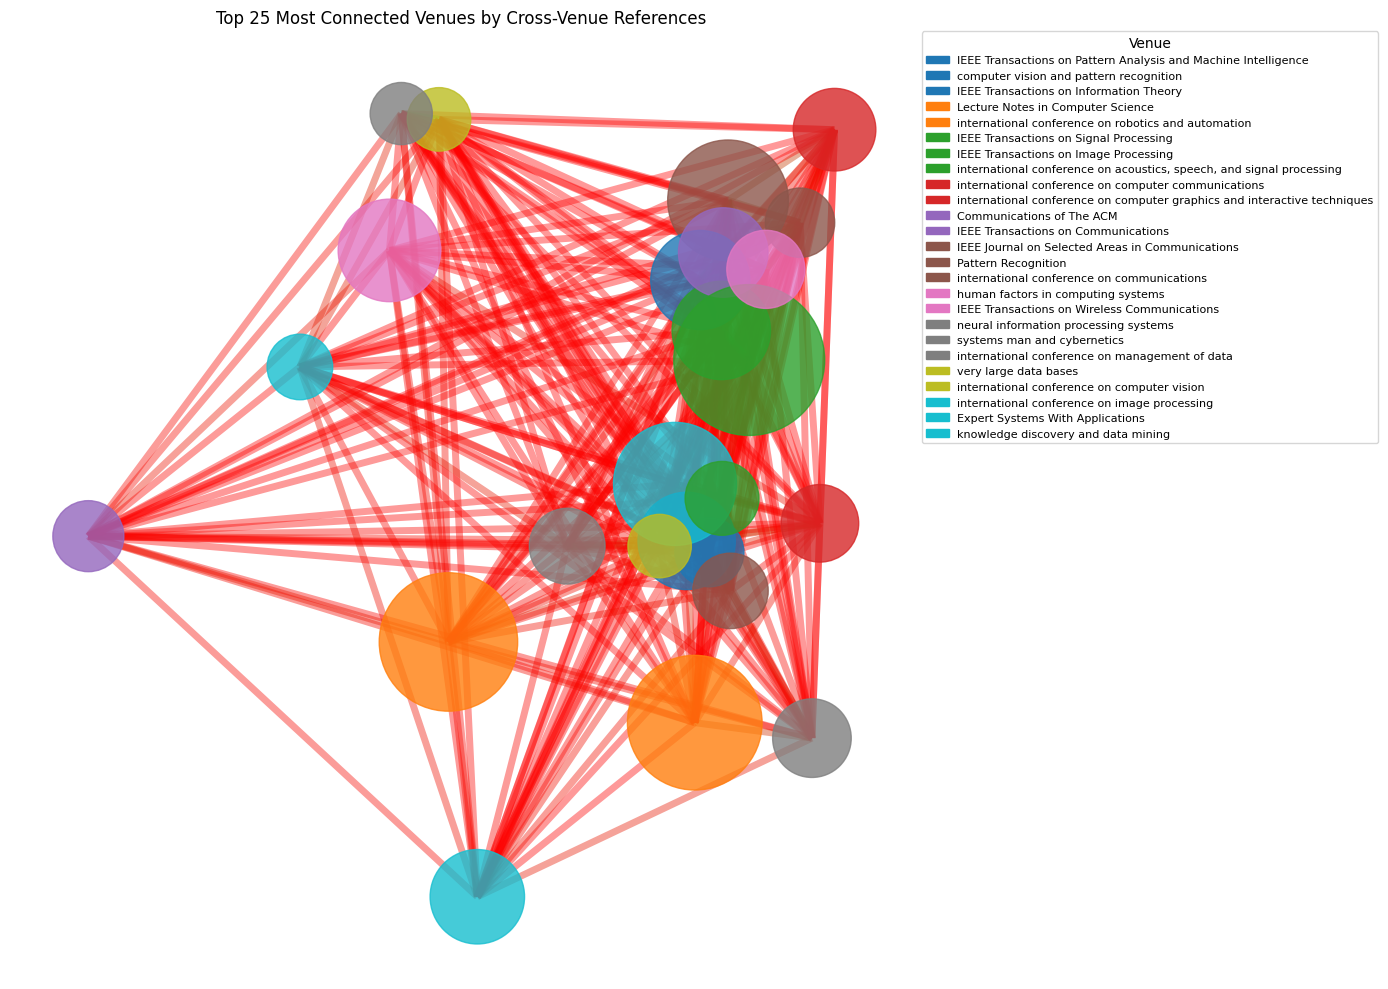

In [9]:
"""Task 1: Map Co-Author Networks Within and Across Venues/Conferences"""

sample_set = papers[
    papers['venue'].notna()
    & (papers['venue'].astype(str).str.strip() != '')
    & (papers['n_citation'] > 0)
    & papers['references'].notna()
].sample(n=1000000, random_state=42)


# Build venue-level graph based on cross-venue references
venue_published = {}  
venue_referenced = {}

for paper in sample_set.itertuples():
    venue = paper.venue
    if venue not in venue_published:
        venue_published[venue] = []
        venue_referenced[venue] = []
    venue_published[venue].append(paper.id)
    if isinstance(paper.references, list):
        venue_referenced[venue].extend(paper.references)

# Inverted index: paper_id -> venue (for papers in our sample only)
paper_to_venue = {pid: venue for venue, pids in venue_published.items() for pid in pids}

# Build graph nodes
venue_graph = nx.Graph()
for venue, pids in venue_published.items():
    venue_graph.add_node(venue, size=len(pids))

# Count cross-venue references in a single pass over all references (O(total_references))
edge_weights = {}
for src_venue, refs in venue_referenced.items():
    for ref_id in refs:
        tgt_venue = paper_to_venue.get(ref_id)
        if tgt_venue and tgt_venue != src_venue:
            key = (min(src_venue, tgt_venue), max(src_venue, tgt_venue))
            edge_weights[key] = edge_weights.get(key, 0) + 1

for (v1, v2), weight in edge_weights.items():
    venue_graph.add_edge(v1, v2, weight=weight)


# Filter to the top N venues ranked by total weighted degree (sum of cross-venue reference weights)
TOP_N = 25
scores = {node: venue_graph.degree(node, weight='weight') for node in venue_graph.nodes()}
top_venues = sorted(scores, key=scores.get, reverse=True)[:TOP_N]
subgraph = venue_graph.subgraph(top_venues)

cmap = plt.cm.get_cmap('tab10', TOP_N)
venue_colors = {venue: cmap(i) for i, venue in enumerate(top_venues)}

nodes = list(subgraph.nodes())
max_weight = max((d['weight'] for _, _, d in subgraph.edges(data=True)), default=1)
no_edge_dist = 10.0 / max_weight  # much larger than any connected pair's distance

layout_graph = nx.complete_graph(len(nodes))
layout_graph = nx.relabel_nodes(layout_graph, dict(enumerate(nodes)))
for u, v in layout_graph.edges():
    if subgraph.has_edge(u, v):
        layout_graph[u][v]['weight'] = 1.0 / subgraph[u][v]['weight']
    else:
        layout_graph[u][v]['weight'] = no_edge_dist

pos = nx.kamada_kawai_layout(layout_graph, weight='weight')

plt.figure(figsize=(14, 10))
node_sizes = [subgraph.nodes[n]['size'] for n in subgraph.nodes()]
edge_widths = [subgraph[u][v]['weight'] / 10 for u, v in subgraph.edges()]
node_colors = [venue_colors[n] for n in subgraph.nodes()]

weights = np.array([subgraph[u][v]['weight'] for u, v in subgraph.edges()], dtype=float)
norm_weights = (weights - weights.min()) / (weights.max() - weights.min()) if weights.max() > weights.min() else np.zeros_like(weights)
edge_colors = [(1 - w, w, 0, 1) for w in norm_weights]  # (R, G, B, A): red -> green

nx.draw_networkx_edges(subgraph, pos, width=5, alpha=0.4, edge_color=edge_colors)
nx.draw_networkx_nodes(subgraph, pos, node_size=node_sizes, alpha=0.8, node_color=node_colors)

from matplotlib.patches import Patch
legend_handles = [Patch(color=venue_colors[v], label=v) for v in top_venues]
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=8, title='Venue')

plt.title(f'Top {TOP_N} Most Connected Venues by Cross-Venue References')
plt.axis('off')
plt.tight_layout()
plt.show()


/tmp/ipykernel_5621/2946974603.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  author_cmap = plt.cm.get_cmap('tab20', TOP_N_AUTHORS)


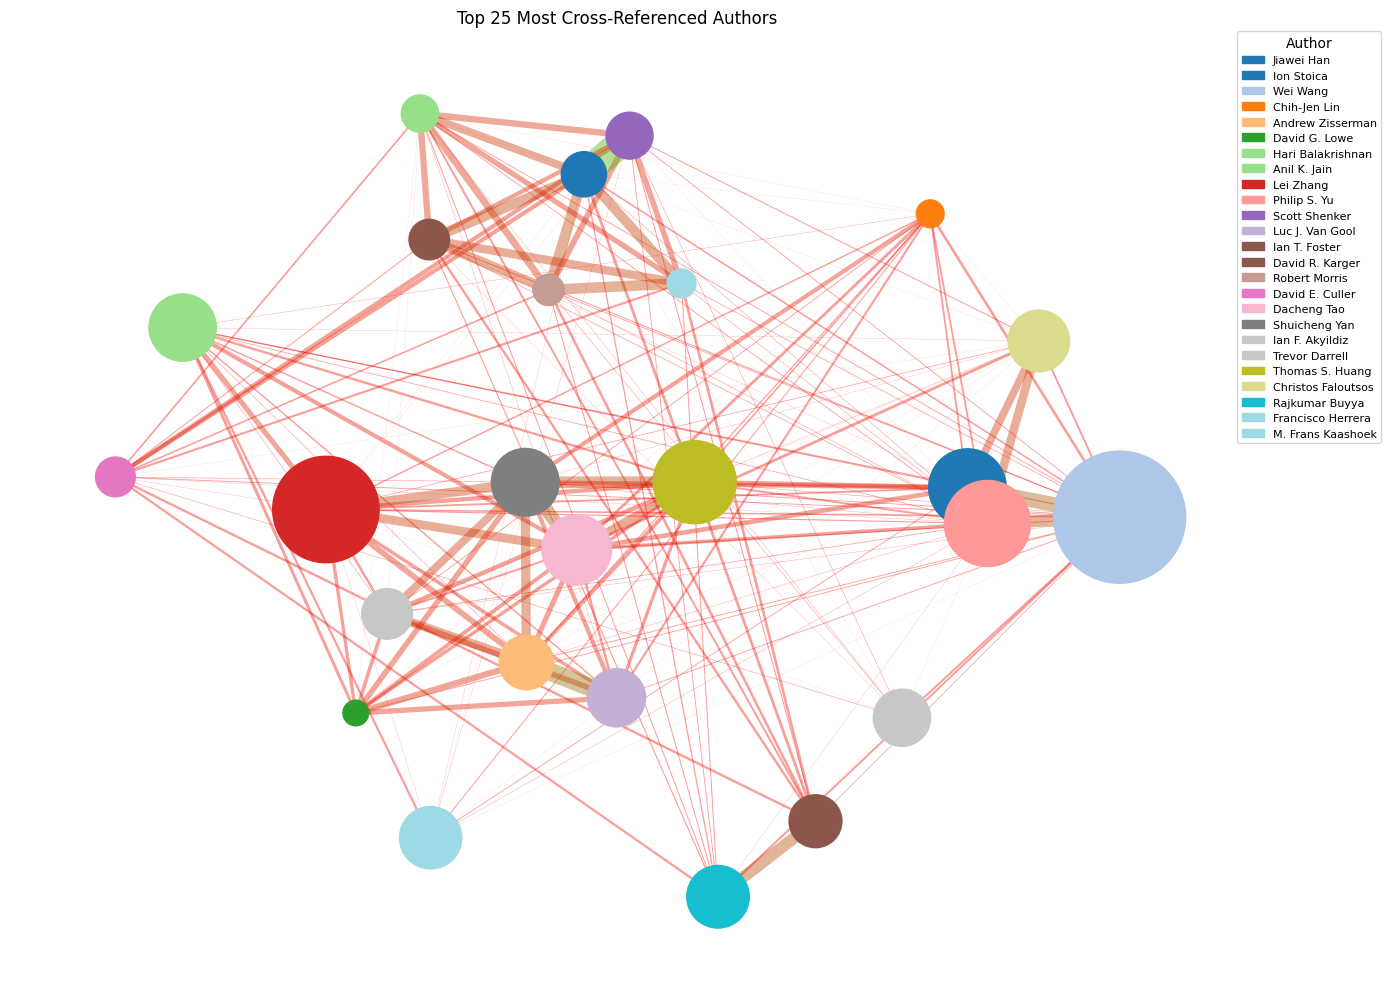

In [6]:
# Build author -> published papers mapping and paper -> authors index in a single pass
author_published = {}
paper_to_authors = {}

for paper in sample_set.itertuples():
    if not isinstance(paper.authors, list):
        continue
    paper_to_authors[paper.id] = paper.authors
    for author in paper.authors:
        if author not in author_published:
            author_published[author] = []
        author_published[author].append(paper.id)

# Count cross-author references: iterate each paper once instead of once per co-author,
# avoiding the A×R duplication of the author_referenced approach
author_edge_weights = {}
for paper in sample_set.itertuples():
    if not isinstance(paper.authors, list) or not isinstance(paper.references, list):
        continue
    citing_authors = paper.authors
    for ref_id in paper.references:
        cited_authors = paper_to_authors.get(ref_id)
        if not cited_authors:
            continue
        for src in citing_authors:
            for tgt in cited_authors:
                if src != tgt:
                    key = (min(src, tgt), max(src, tgt))
                    author_edge_weights[key] = author_edge_weights.get(key, 0) + 1

# Build author graph
author_graph = nx.Graph()
for author, pids in author_published.items():
    author_graph.add_node(author, size=len(pids))
for (a1, a2), weight in author_edge_weights.items():
    author_graph.add_edge(a1, a2, weight=weight)


# Filter to top N authors by weighted degree
TOP_N_AUTHORS = 25
author_scores = {node: author_graph.degree(node, weight='weight') for node in author_graph.nodes()}
top_authors = sorted(author_scores, key=author_scores.get, reverse=True)[:TOP_N_AUTHORS]
author_subgraph = author_graph.subgraph(top_authors)

author_cmap = plt.cm.get_cmap('tab20', TOP_N_AUTHORS)
author_colors = {author: author_cmap(i) for i, author in enumerate(top_authors)}

author_max_weight = max((d['weight'] for _, _, d in author_subgraph.edges(data=True)), default=1)
author_no_edge_dist = 10.0 / author_max_weight

author_layout_graph = nx.complete_graph(len(top_authors))
author_layout_graph = nx.relabel_nodes(author_layout_graph, dict(enumerate(top_authors)))
for u, v in author_layout_graph.edges():
    if author_subgraph.has_edge(u, v):
        author_layout_graph[u][v]['weight'] = 1.0 / author_subgraph[u][v]['weight']
    else:
        author_layout_graph[u][v]['weight'] = author_no_edge_dist

author_pos = nx.kamada_kawai_layout(author_layout_graph, weight='weight')

plt.figure(figsize=(14, 10))
author_node_sizes = [author_subgraph.nodes[n]['size'] * 10 for n in author_subgraph.nodes()]
author_edge_raw = np.array([author_subgraph[u][v]['weight'] for u, v in author_subgraph.edges()], dtype=float)
author_edge_widths = [author_subgraph[u][v]['weight'] / 10 for u, v in author_subgraph.edges()]
author_norm_weights = (author_edge_raw - author_edge_raw.min()) / (author_edge_raw.max() - author_edge_raw.min()) if author_edge_raw.max() > author_edge_raw.min() else np.zeros_like(author_edge_raw)
author_edge_colors = [(1 - w, w, 0, 1) for w in author_norm_weights]
author_node_colors = [author_colors[n] for n in author_subgraph.nodes()]

nx.draw_networkx_edges(author_subgraph, author_pos, width=author_edge_widths, alpha=0.4, edge_color=author_edge_colors)
nx.draw_networkx_nodes(author_subgraph, author_pos, node_size=author_node_sizes, node_color=author_node_colors)

from matplotlib.patches import Patch
author_legend_handles = [Patch(color=author_colors[a], label=a) for a in top_authors]
plt.legend(handles=author_legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=8, title='Author')

plt.title(f'Top {TOP_N_AUTHORS} Most Cross-Referenced Authors')
plt.axis('off')
plt.tight_layout()
plt.show()


Full author graph  : 875,383 nodes, 32,026,639 edges
Core graph (filtered): 232,135 nodes, 5,509,119 edges

Total communities detected: 653
Showing top 10 communities by member count:

  Community  1 — 27820 authors | hub: Andrew Zisserman
  Community  2 — 23568 authors | hub: Ion Stoica
  Community  3 — 20999 authors | hub: Jiawei Han
  Community  4 — 20931 authors | hub: Edmund M. Clarke
  Community  5 — 18689 authors | hub: Onur Mutlu
  Community  6 — 18621 authors | hub: Francisco Herrera
  Community  7 — 18201 authors | hub: Sebastian Thrun
  Community  8 — 15805 authors | hub: Jeffrey G. Andrews
  Community  9 — 11825 authors | hub: Dan Boneh
  Community 10 — 10734 authors | hub: Anind K. Dey


/tmp/ipykernel_5621/565525706.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  comm_cmap = plt.cm.get_cmap('tab10', TOP_COMMUNITIES)


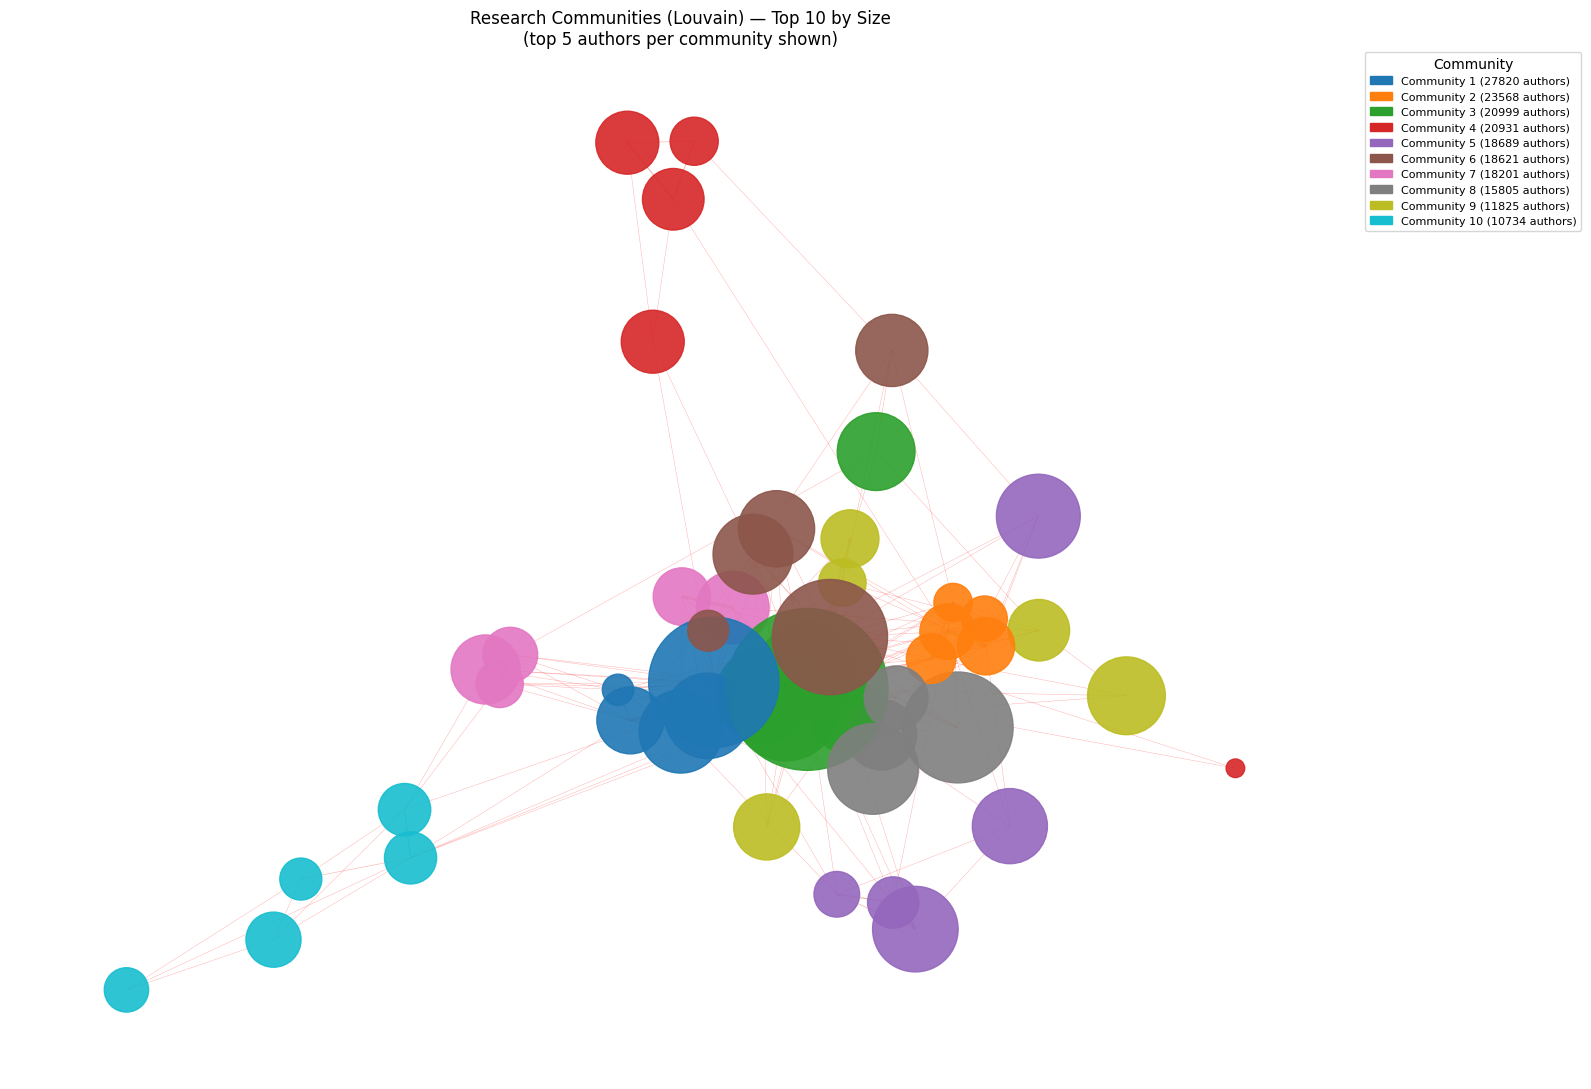

In [10]:
"""Task 2: Use graph clustering to identify research communities/groups"""
import community as community_louvain
from matplotlib.patches import Patch

# Filter to a "core" subgraph before running Louvain.
# Authors with very few papers contribute little to community structure and
# dominate runtime.  Keeping only authors with >= MIN_PAPERS publications
# and edges with >= MIN_EDGE_WEIGHT cross-citations reduces the graph to a
# tractable size while preserving the meaningful communities.
MIN_PAPERS = 3        # minimum papers published by an author
MIN_EDGE_WEIGHT = 2   # minimum cross-citation weight to keep an edge

core_nodes = [n for n, d in author_graph.nodes(data=True) if d.get('size', 0) >= MIN_PAPERS]
core_graph = author_graph.subgraph(core_nodes).copy()

# Remove weak edges in-place
weak_edges = [(u, v) for u, v, d in core_graph.edges(data=True) if d.get('weight', 0) < MIN_EDGE_WEIGHT]
core_graph.remove_edges_from(weak_edges)

# Drop isolated nodes that lost all edges after the edge filter
core_graph.remove_nodes_from(list(nx.isolates(core_graph)))

print(f"Full author graph  : {author_graph.number_of_nodes():>7,} nodes, {author_graph.number_of_edges():>8,} edges")
print(f"Core graph (filtered): {core_graph.number_of_nodes():>7,} nodes, {core_graph.number_of_edges():>8,} edges")

# Run Louvain community detection on the filtered core graph
partition = community_louvain.best_partition(core_graph, weight='weight', random_state=42)

# Summarise: community id -> list of authors
communities = {}
for author, comm_id in partition.items():
    communities.setdefault(comm_id, []).append(author)

TOP_COMMUNITIES = 10
# How many representative authors to show per community in the visualisation.
# Keeping this small is the key to fast layout computation.
TOP_AUTHORS_PER_COMMUNITY = 5

top_comm_ids = sorted(communities, key=lambda c: len(communities[c]), reverse=True)[:TOP_COMMUNITIES]

print(f"\nTotal communities detected: {len(communities)}")
print(f"Showing top {TOP_COMMUNITIES} communities by member count:\n")
for rank, cid in enumerate(top_comm_ids, 1):
    members = communities[cid]
    hub = max(members, key=lambda a: core_graph.degree(a, weight='weight'))
    print(f"  Community {rank:>2} — {len(members):>4} authors | hub: {hub}")


# Visualise: for each community take only the top K authors by weighted degree.
# This keeps the visualisation graph small (TOP_COMMUNITIES * TOP_AUTHORS_PER_COMMUNITY nodes)
# so layout runs in seconds instead of minutes.
vis_authors = []
for cid in top_comm_ids:
    members = communities[cid]
    top_k = sorted(members, key=lambda a: core_graph.degree(a, weight='weight'), reverse=True)[:TOP_AUTHORS_PER_COMMUNITY]
    vis_authors.extend(top_k)

comm_subgraph = core_graph.subgraph(vis_authors)

comm_cmap = plt.cm.get_cmap('tab10', TOP_COMMUNITIES)
comm_color_map = {cid: comm_cmap(i) for i, cid in enumerate(top_comm_ids)}
comm_node_colors = [comm_color_map[partition[n]] for n in comm_subgraph.nodes()]

# spring_layout: heavier edges = shorter springs = nodes pulled closer together.
# Unconnected node pairs only experience repulsion so they spread apart naturally —
# no need to build an expensive complete graph.
comm_pos = nx.spring_layout(
    comm_subgraph,
    weight='weight',
    seed=42,
    k=3 / (len(vis_authors) ** 0.5),
    iterations=100,
)

comm_node_sizes = [core_graph.nodes[n]['size'] * 15 for n in comm_subgraph.nodes()]
comm_edge_raw = np.array([comm_subgraph[u][v]['weight'] for u, v in comm_subgraph.edges()], dtype=float)
comm_edge_widths = (np.clip(comm_edge_raw / comm_edge_raw.max() * 5, 0.3, 5).tolist()
                    if comm_edge_raw.size else [])
comm_norm_e = ((comm_edge_raw - comm_edge_raw.min()) / (comm_edge_raw.max() - comm_edge_raw.min())
               if comm_edge_raw.size and comm_edge_raw.max() > comm_edge_raw.min()
               else np.zeros_like(comm_edge_raw))
comm_edge_colors = [(1 - w, w, 0, 1) for w in comm_norm_e]

plt.figure(figsize=(16, 11))
nx.draw_networkx_edges(comm_subgraph, comm_pos, width=comm_edge_widths,
                       alpha=0.35, edge_color=comm_edge_colors)
nx.draw_networkx_nodes(comm_subgraph, comm_pos, node_size=comm_node_sizes,
                       node_color=comm_node_colors, alpha=0.9)

legend_handles = [
    Patch(color=comm_color_map[cid],
          label=f"Community {rank} ({len(communities[cid])} authors)")
    for rank, cid in enumerate(top_comm_ids, 1)
]
plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1),
           borderaxespad=0, fontsize=8, title='Community')
plt.title(
    f'Research Communities (Louvain) — Top {TOP_COMMUNITIES} by Size'
    f'\n(top {TOP_AUTHORS_PER_COMMUNITY} authors per community shown)'
)
plt.axis('off')
plt.tight_layout()
plt.show()


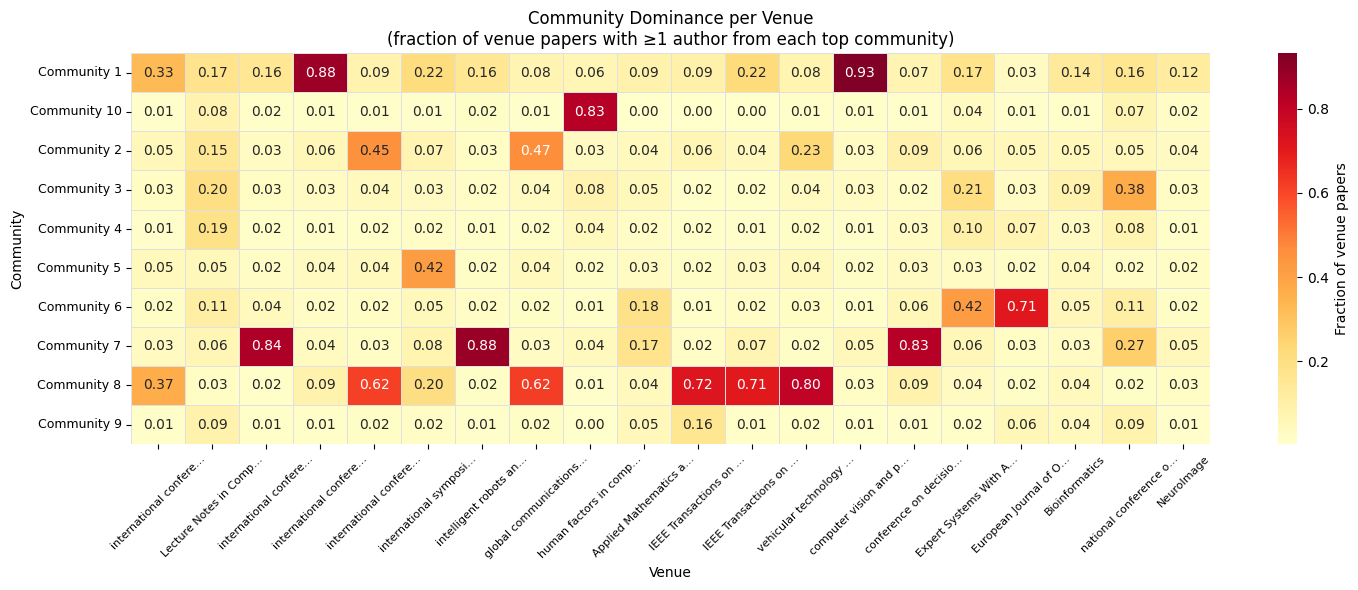

/tmp/ipykernel_5621/2186113849.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  bar_cmap = plt.cm.get_cmap("tab10", TOP_COMMUNITIES)


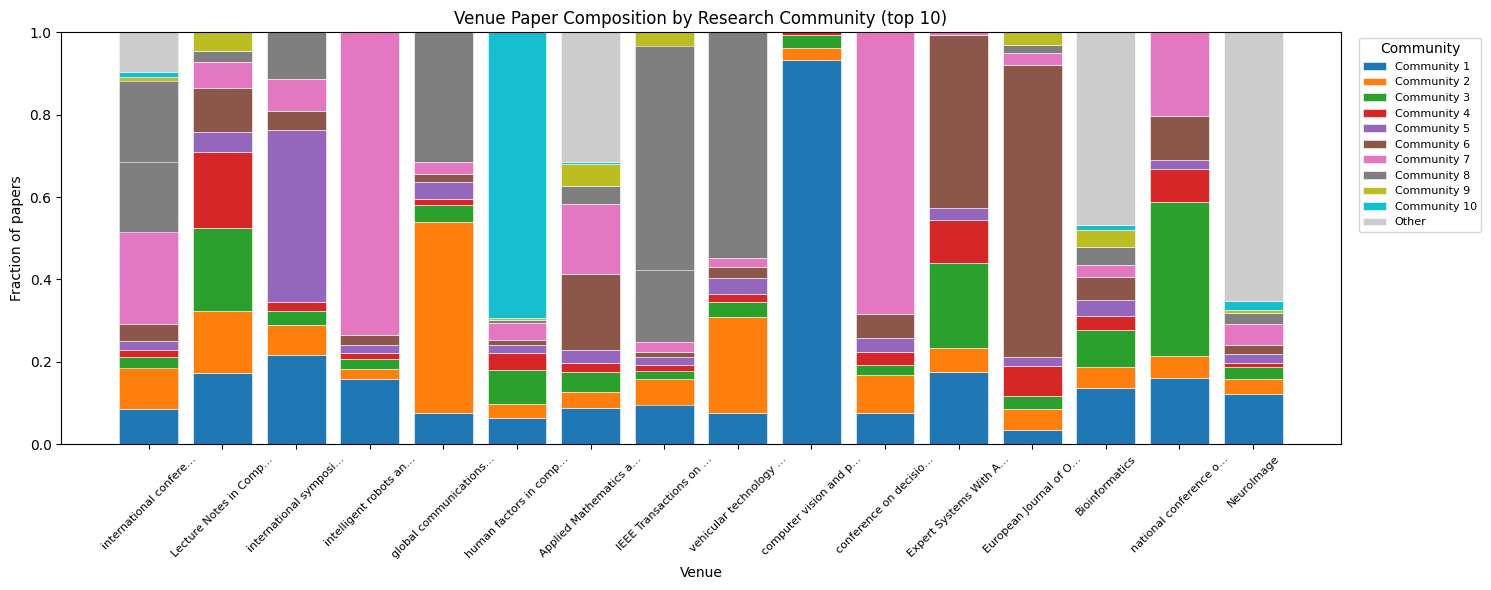

Dominant community per venue (by fraction):



TypeError: unsupported format string passed to Series.__format__

In [11]:
"""Task 3: Analyze collaboration patterns — do certain author groups dominate certain venues?"""
import seaborn as sns

TOP_VENUES_T3 = 20  # how many venues to include

# --- Map each author (in the top communities) to a readable label ---
author_to_comm_label = {}
for rank, cid in enumerate(top_comm_ids, 1):
    for a in communities[cid]:
        author_to_comm_label[a] = f"Community {rank}"

# --- Work with papers that have a valid venue and at least one author ---
valid = (
    sample_set['venue'].notna()
    & (sample_set['venue'].astype(str).str.strip() != '')
    & sample_set['authors'].notna()
)
working = sample_set.loc[valid, ['id', 'venue', 'authors']].copy()

# Choose the top N venues by paper count
venue_totals = working.groupby('venue').size()
top_venue_list = venue_totals.nlargest(TOP_VENUES_T3).index.tolist()
working = working[working['venue'].isin(top_venue_list)]

# Explode so each row is (paper_id, venue, author), map to community label
exploded = working.explode('authors').rename(columns={'authors': 'author'})
exploded['community'] = exploded['author'].map(author_to_comm_label)
exploded = exploded.dropna(subset=['community'])

# Deduplicate: count each (paper, community) pair only once
# (avoids inflating when several co-authors belong to the same community)
unique_pairs = exploded.drop_duplicates(subset=['id', 'community'])

# Build community × venue count matrix, then normalise by venue total
count_matrix = (
    unique_pairs.groupby(['community', 'venue'])
    .size()
    .unstack('venue', fill_value=0)
    .reindex(columns=top_venue_list, fill_value=0)
)
norm_matrix = count_matrix.divide(venue_totals[top_venue_list], axis=1)

# Shorten long venue names so they fit on axes
def _shorten(name, n=22):
    return name if len(name) <= n else name[: n - 1] + "…"

short_venues = [_shorten(v) for v in top_venue_list]
norm_matrix.columns = short_venues
count_matrix.columns = short_venues

# ── Plot 1: Heatmap — fraction of each venue's papers authored by each community ──
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    norm_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#e0e0e0",
    cbar_kws={"label": "Fraction of venue papers"},
    ax=ax,
)
ax.set_title(
    "Community Dominance per Venue\n"
    "(fraction of venue papers with ≥1 author from each top community)",
    fontsize=12,
)
ax.set_xlabel("Venue", fontsize=10)
ax.set_ylabel("Community", fontsize=10)
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.tick_params(axis="y", labelrotation=0, labelsize=9)
plt.tight_layout()
plt.show()


# ── Plot 2: Stacked bar — per-venue paper share broken down by community ──
community_labels = [f"Community {r}" for r in range(1, TOP_COMMUNITIES + 1)]

bar_cmap = plt.cm.get_cmap("tab10", TOP_COMMUNITIES)
colors = {f"Community {r}": bar_cmap(r - 1) for r in range(1, TOP_COMMUNITIES + 1)}
colors["Other"] = "#cccccc"

# "Other" absorbs the remainder so bars sum to 1
other_row = (1.0 - norm_matrix.sum(axis=0)).clip(lower=0)
plot_df = norm_matrix.reindex(community_labels, fill_value=0)
plot_df.loc["Other"] = other_row

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(short_venues))
for label in community_labels + ["Other"]:
    vals = plot_df.loc[label].values.astype(float)
    ax.bar(short_venues, vals, bottom=bottom,
           color=colors[label], label=label, edgecolor="white", linewidth=0.4)
    bottom += vals

ax.set_title(
    f"Venue Paper Composition by Research Community (top {TOP_COMMUNITIES})",
    fontsize=12,
)
ax.set_xlabel("Venue", fontsize=10)
ax.set_ylabel("Fraction of papers", fontsize=10)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", labelrotation=45, labelsize=8)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, title="Community")
plt.tight_layout()
plt.show()


# ── Summary: dominant community per venue ──
print("Dominant community per venue (by fraction):\n")
for short, full in zip(short_venues, top_venue_list):
    dominant = norm_matrix[short].idxmax()
    frac = norm_matrix[short].max()
    total = int(venue_totals[full])
    print(f"  {short:<24}  →  {dominant}  ({frac:.1%} of {total:,} papers)")
